## Homework 1: Aircraft inventory analysis
### Task 1: Investigating missing data

In [2]:
! pip install pandas numpy matplotlib missingno seaborn


[notice] A new release of pip is available: 25.0.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import missingno as msno
import seaborn as sns

In [5]:
aircraft_data = pd.read_csv('T_F41SCHEDULE_B43.csv', low_memory=False)
aircraft_data.shape

(132313, 17)

In [6]:
aircraft_data.head()

,YEAR,CARRIER,CARRIER_NAME,MANUFACTURE_YEAR,UNIQUE_CARRIER_NAME,SERIAL_NUMBER,TAIL_NUMBER,AIRCRAFT_STATUS,OPERATING_STATUS,NUMBER_OF_SEATS,MANUFACTURER,AIRCRAFT_TYPE,MODEL,CAPACITY_IN_POUNDS,ACQUISITION_DATE,AIRLINE_ID,UNIQUE_CARRIER
0,2006,16,PSA Airlines Inc.,2003.0,PSA Airlines Inc.,7858,N202PS,B,Y,50.0,CANADAIR,NaN,CRJ-2/4,47000.0,10/28/2003 12:00:00 AM,20397.0,16
1,2006,16,PSA Airlines Inc.,2003.0,PSA Airlines Inc.,7860,N206PS,B,Y,50.0,CANADAIR,NaN,CRJ-2/4,47000.0,10/30/2003 12:00:00 AM,20397.0,16
2,2006,16,PSA Airlines Inc.,2003.0,PSA Airlines Inc.,7873,N207PS,B,Y,50.0,CANADAIR,NaN,CRJ-2/4,47000.0,11/26/2003 12:00:00 AM,20397.0,16
3,2006,16,PSA Airlines Inc.,2003.0,PSA Airlines Inc.,7874,N209PS,B,Y,50.0,CANADAIR,NaN,CRJ-2/4,47000.0,12/4/2003 12:00:00 AM,20397.0,16
4,2006,16,PSA Airlines Inc.,2003.0,PSA Airlines Inc.,7879,N213PS,B,Y,50.0,CANADAIR,NaN,CRJ-2/4,47000.0,12/16/2003 12:00:00 AM,20397.0,16


In [7]:
aircraft_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 132313 entries, 0 to 132312
Data columns (total 17 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   YEAR                 132313 non-null  int64  
 1   CARRIER              132264 non-null  object 
 2   CARRIER_NAME         132208 non-null  object 
 3   MANUFACTURE_YEAR     132310 non-null  float64
 4   UNIQUE_CARRIER_NAME  132208 non-null  object 
 5   SERIAL_NUMBER        132313 non-null  object 
 6   TAIL_NUMBER          132313 non-null  object 
 7   AIRCRAFT_STATUS      132313 non-null  object 
 8   OPERATING_STATUS     132313 non-null  object 
 9   NUMBER_OF_SEATS      119075 non-null  float64
 10  MANUFACTURER         132313 non-null  object 
 11  AIRCRAFT_TYPE        102380 non-null  object 
 12  MODEL                132302 non-null  object 
 13  CAPACITY_IN_POUNDS   118981 non-null  float64
 14  ACQUISITION_DATE     131346 non-null  object 
 15  AIRLINE_ID       

In [8]:
missing_counts = aircraft_data.isnull().sum()
missing_counts[missing_counts > 0]

CARRIER                   49
CARRIER_NAME             105
MANUFACTURE_YEAR           3
UNIQUE_CARRIER_NAME      105
NUMBER_OF_SEATS        13238
AIRCRAFT_TYPE          29933
MODEL                     11
CAPACITY_IN_POUNDS     13332
ACQUISITION_DATE         967
AIRLINE_ID               105
UNIQUE_CARRIER           164
dtype: int64

<Axes: >

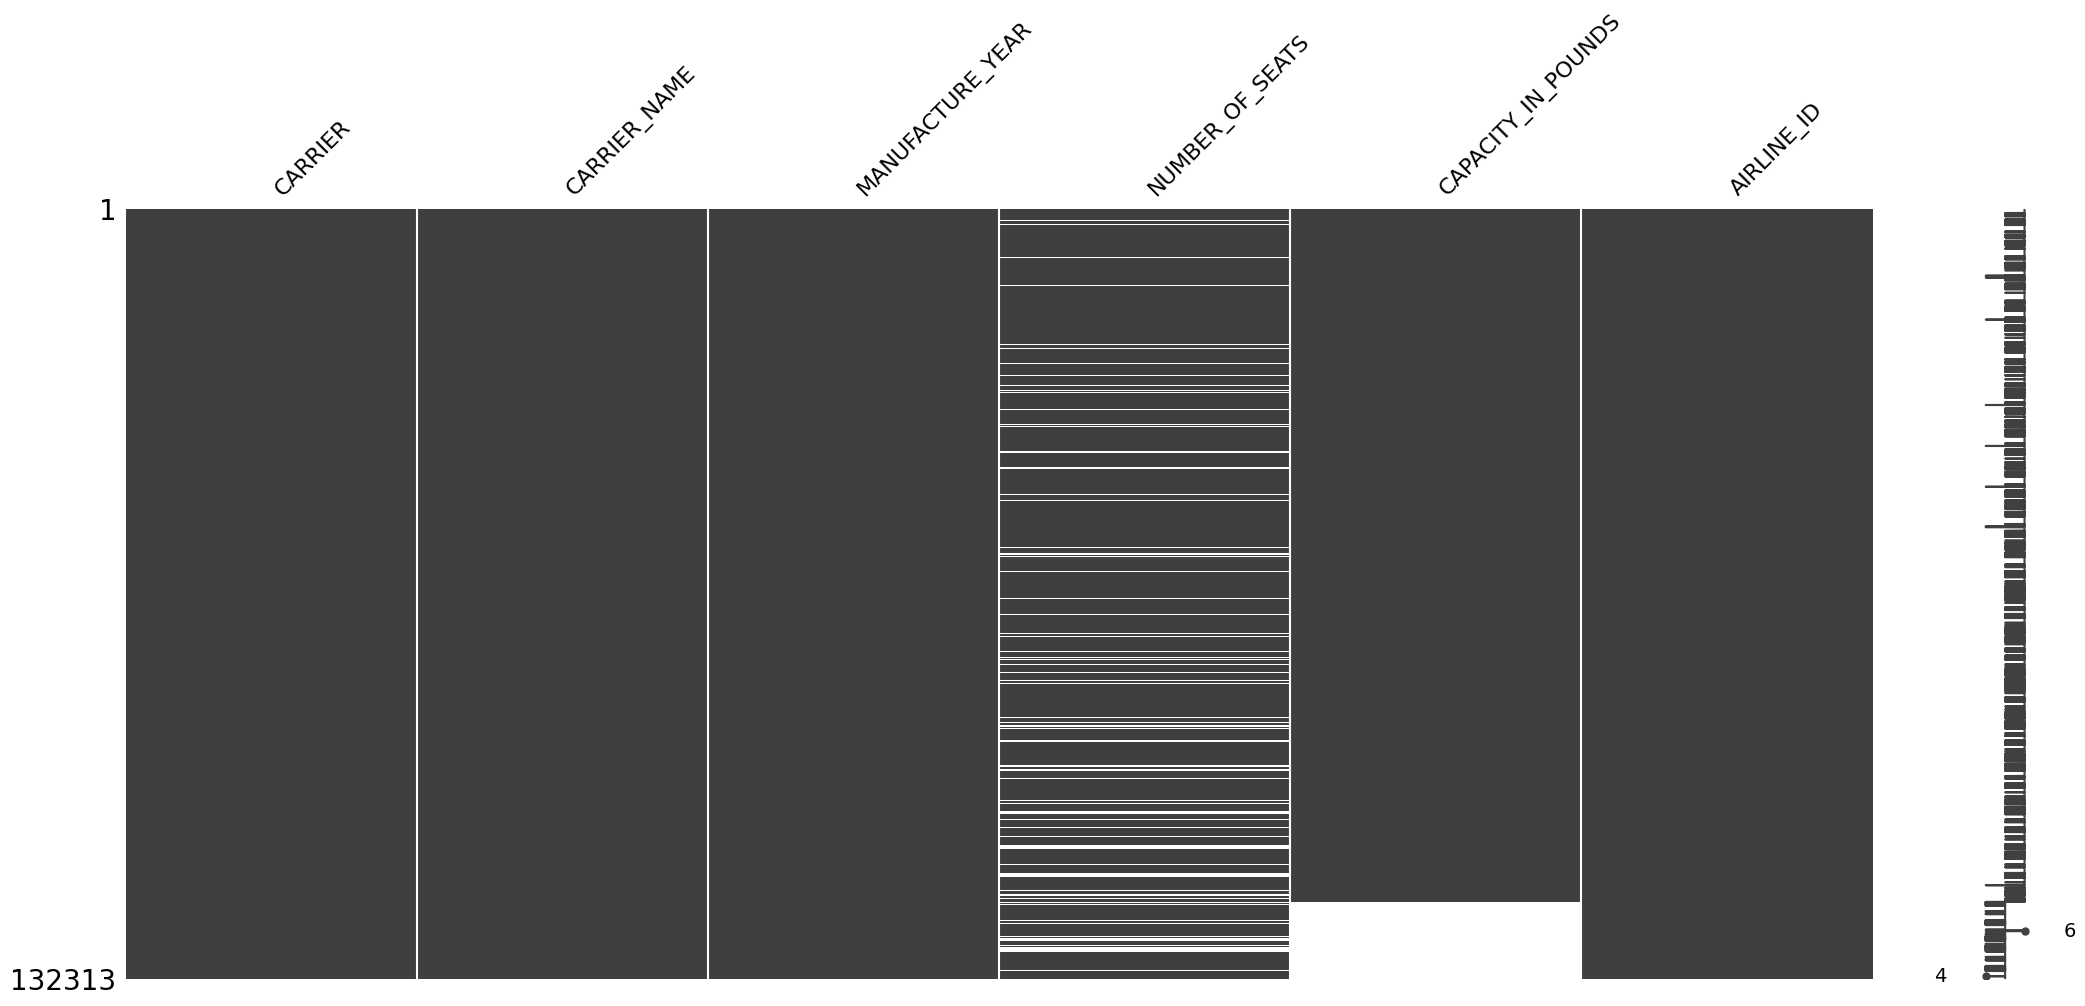

In [9]:
cols_to_investigate = ['CARRIER', 'CARRIER_NAME', 'MANUFACTURE_YEAR', 'NUMBER_OF_SEATS', 'CAPACITY_IN_POUNDS', 'AIRLINE_ID']
msno.matrix(aircraft_data[cols_to_investigate])

**CARRIER, CARRIER_NAME, UNIQUE_CARRIER**

In [18]:
# Rows with CARRIER missing
missing_carrier = aircraft_data[aircraft_data['CARRIER'].isnull()]
missing_carrier['CARRIER_NAME'].value_counts()

CARRIER_NAME
North American Airlines    49
Name: count, dtype: int64

In [21]:
missing_carrier.head()

,YEAR,CARRIER,CARRIER_NAME,MANUFACTURE_YEAR,UNIQUE_CARRIER_NAME,SERIAL_NUMBER,TAIL_NUMBER,AIRCRAFT_STATUS,OPERATING_STATUS,NUMBER_OF_SEATS,MANUFACTURER,AIRCRAFT_TYPE,MODEL,CAPACITY_IN_POUNDS,ACQUISITION_DATE,AIRLINE_ID,UNIQUE_CARRIER
11776,2007,NaN,North American Airlines,1993.0,North American Airlines,26257,N760NA,B,Y,NaN,BOEING,NaN,B767-3,104476.0,3/23/2004 12:00:00 AM,20415.0,NaN
11777,2007,NaN,North American Airlines,1995.0,North American Airlines,26277,N750NA,B,Y,NaN,BOEING,NaN,B757-2,58491.0,1/27/1995 12:00:00 AM,20415.0,NaN
11778,2007,NaN,North American Airlines,1996.0,North American Airlines,28039,N769NA,B,Y,NaN,BOEING,NaN,B767-3,100500.0,2/19/2007 12:00:00 AM,20415.0,NaN
11779,2007,NaN,North American Airlines,1996.0,North American Airlines,28098,N765NA,B,Y,NaN,BOEING,NaN,B767-3,94523.0,3/23/2006 12:00:00 AM,20415.0,NaN
11780,2007,NaN,North American Airlines,1997.0,North American Airlines,28174,N752NA,B,Y,NaN,BOEING,NaN,B757-2,58948.0,5/12/1999 12:00:00 AM,20415.0,NaN


##### For North American Airlines, the IATA carrier code is "NA". In some years (eg. 2007-2008, 2010-2013) the `CARRIER` field was left blank, while in other years (2009) it was recorded as "NA ". The `UNIQUE_CARRIER` column is missing for all 59 rows. Since we know the carrier code from the rows that do have it and from the airline's name, we can fill these in. This is not truly missing data, it's an inconsistent recording issue.
 

In [25]:
north_american_airlines = aircraft_data[aircraft_data['CARRIER_NAME'] == 'North American Airlines']
print("total north american rows:", len(north_american_airlines))
print("total north american rows missing carrier:", len(north_american_airlines[north_american_airlines['CARRIER'].isnull()]))
north_american_missing_unique_carrier = north_american_airlines[north_american_airlines['UNIQUE_CARRIER'].isnull()]
print("total north american missing unique carrier:", len(north_american_missing_unique_carrier))

total north american rows: 59
total north american rows missing carrier: 49
total north american missing unique carrier: 59


In [33]:
def fill_north_american_carrier(row):
    mask = aircraft_data['CARRIER_NAME'] == 'North American Airlines'
    aircraft_data.loc[mask, 'CARRIER'] = 'NA'
    aircraft_data.loc[mask, 'UNIQUE_CARRIER'] = 'NA'
    return aircraft_data
aircraft_data = fill_north_american_carrier(aircraft_data)
#verify it's fixed
fixed_north_american_airlines = aircraft_data[aircraft_data['CARRIER_NAME'] == 'North American Airlines']
print("total north american rows still missing carrier:", len(fixed_north_american_airlines[fixed_north_american_airlines['CARRIER'].isnull()]))
print("total north american rows still missing unique carrier:", len(fixed_north_american_airlines[fixed_north_american_airlines['UNIQUE_CARRIER'].isnull()]))

total north american rows still missing carrier: 0
total north american rows still missing unique carrier: 0


In [38]:
#rows still missing unique carrier
missing_unique_carrier = aircraft_data[aircraft_data['UNIQUE_CARRIER'].isnull()]
print("rows still missing unique carrier:", len(missing_unique_carrier))
print("Their CARRIER codes:", missing_unique_carrier['CARRIER'].unique())

rows still missing unique carrier: 105
Their CARRIER codes: ['L4' 'OH']


In [42]:
missing_airline_id = aircraft_data[aircraft_data['AIRLINE_ID'].isnull()]
print("rows missing airline id:", len(missing_airline_id))
print("Their CARRIER codes:", missing_airline_id['CARRIER'].unique())

rows missing airline id: 105
Their CARRIER codes: ['L4' 'OH']


In [43]:
has_name_no_id = aircraft_data[aircraft_data['CARRIER_NAME'].notna() & aircraft_data['AIRLINE_ID'].isna()]
print("Has CARRIER_NAME but missing AIRLINE_ID:", len(has_name_no_id))

Has CARRIER_NAME but missing AIRLINE_ID: 0


In [44]:
#L4 carrier
l4_known = aircraft_data[(aircraft_data['CARRIER'] == 'L4') & (aircraft_data['CARRIER_NAME'].notna())]

print("L4 known info:")
print(f"  Name: {l4_known.iloc[0]['CARRIER_NAME']}")
print(f"  AIRLINE_ID: {l4_known.iloc[0]['AIRLINE_ID']}")
print()

#OH carrier
oh_known = aircraft_data[(aircraft_data['CARRIER'] == 'OH') & (aircraft_data['CARRIER_NAME'].notna())]
print("OH known info:")
print(f"  Name: {oh_known.iloc[0]['CARRIER_NAME']}")
print(f"  AIRLINE_ID: {oh_known.iloc[0]['AIRLINE_ID']}")

L4 known info:
  Name: Lynx Aviation d/b/a Frontier Airlines
  AIRLINE_ID: 21217.0

OH known info:
  Name: Comair Inc.
  AIRLINE_ID: 20417.0


##### We see the same rows missing unique_carrier also miss airline_id. We can fix these missing values by filling them with the known values.

In [45]:
#fix unique carrier and airline id
def fix_carrier_name_l4(df):
    mask = (df['CARRIER'] == 'L4') & (df['CARRIER_NAME'].isna())
    df.loc[mask, 'CARRIER_NAME'] = 'Lynx Aviation d/b/a Frontier Airlines'
    df.loc[mask, 'UNIQUE_CARRIER_NAME'] = 'Lynx Aviation d/b/a Frontier Airlines'
    df.loc[mask, 'AIRLINE_ID'] = 21217.0
    df.loc[mask, 'UNIQUE_CARRIER'] = 'L4'
    return df

def fix_carrier_name_oh(df):
    mask = (df['CARRIER'] == 'OH') & (df['CARRIER_NAME'].isna())
    df.loc[mask, 'CARRIER_NAME'] = 'Comair Inc.'
    df.loc[mask, 'UNIQUE_CARRIER_NAME'] = 'Comair Inc.'
    df.loc[mask, 'AIRLINE_ID'] = 20417.0
    df.loc[mask, 'UNIQUE_CARRIER'] = 'OH'
    return df

aircraft_data = fix_carrier_name_l4(aircraft_data)
aircraft_data = fix_carrier_name_oh(aircraft_data)

print("CARRIER_NAME still missing:", aircraft_data['CARRIER_NAME'].isna().sum())
print("AIRLINE_ID still missing:", aircraft_data['AIRLINE_ID'].isna().sum())
print("UNIQUE_CARRIER still missing:", aircraft_data['UNIQUE_CARRIER'].isna().sum())

CARRIER_NAME still missing: 0
AIRLINE_ID still missing: 0
UNIQUE_CARRIER still missing: 0


**MANUFACTURE_YEAR**

In [47]:
mfg_miss = aircraft_data[aircraft_data['MANUFACTURE_YEAR'].isna()]
print(f"rows missing MANUFACTURE_YEAR:", len(mfg_miss))

rows missing MANUFACTURE_YEAR: 3


In [48]:
print(mfg_miss[['YEAR', 'CARRIER_NAME', 'TAIL_NUMBER', 'MODEL', 'MANUFACTURER']].to_string())

        YEAR       CARRIER_NAME TAIL_NUMBER        MODEL MANUFACTURER
116651  2022     Atlas Air Inc.      N664GT     B747-400       BOEING
124680  2023  Endeavor Air Inc.      N655CA  CL-600-2C10   BOMBARDIER
124681  2023  Endeavor Air Inc.      N690CA  CL-600-2C10   BOMBARDIER


In [50]:
#check tail values to see if we can impute from other records
for idx, row in mfg_miss.iterrows():
    tail = row['TAIL_NUMBER']
    same_tail = aircraft_data[(aircraft_data['TAIL_NUMBER'] == tail) & (aircraft_data['MANUFACTURE_YEAR'].notna())]
    if len(same_tail) > 0:
        yr = same_tail.iloc[0]['MANUFACTURE_YEAR']
        print(f"Tail {tail}: found manufacture year = {yr} from other records")
    else:
        print(f"Tail {tail}: no other records with manufacture year available")

Tail N664GT: no other records with manufacture year available
Tail N655CA: found manufacture year = 2004.0 from other records
Tail N690CA: found manufacture year = 2004.0 from other records


In [51]:
#we fix the two using the found records, leave N664GT as is for now
def fix_manufacture_year(df):
    missing_mask = df['MANUFACTURE_YEAR'].isna()
    for idx in df[missing_mask].index:
        tail = df.loc[idx, 'TAIL_NUMBER']
        known = df[(df['TAIL_NUMBER'] == tail) & (df['MANUFACTURE_YEAR'].notna())]
        if len(known) > 0:
            df.loc[idx, 'MANUFACTURE_YEAR'] = known.iloc[0]['MANUFACTURE_YEAR']
    return df

aircraft_data = fix_manufacture_year(aircraft_data)
print("MANUFACTURE_YEAR still missing:", aircraft_data['MANUFACTURE_YEAR'].isna().sum())

MANUFACTURE_YEAR still missing: 1


**NUMBER_OF_SEATS and CAPACITY_IN_POUNDS**

In [52]:
missing_seats = aircraft_data[aircraft_data['NUMBER_OF_SEATS'].isna()]
print(f"rows missing NUMBER_OF_SEATS: {len(missing_seats)}")

missing_capacity_in_pounds = aircraft_data[aircraft_data['CAPACITY_IN_POUNDS'].isna()]
print(f"rows missing CAPACITY_IN_POUNDS: {len(missing_capacity_in_pounds)}")

rows missing NUMBER_OF_SEATS: 13238
rows missing CAPACITY_IN_POUNDS: 13332


In [54]:
#if missingness depends on carrier
seats_miss_rate = aircraft_data.groupby('CARRIER_NAME')['NUMBER_OF_SEATS'].apply(lambda x: x.isna().mean())
print(seats_miss_rate[seats_miss_rate > 0].sort_values(ascending=False).head(10))

CARRIER_NAME
Eastern Airlines f/k/a Dynamic Airways, LLC    1.000000
Dynamic Airways, LLC                           1.000000
North American Airlines                        1.000000
Primaris Airlines Inc.                         1.000000
Omni Air Express                               0.967213
Omni Air International LLC                     0.816514
Hawaiian Airlines Inc.                         0.507212
Ryan International Airlines                    0.453125
ATA Airlines d/b/a ATA                         0.433333
World Airways Inc.                             0.412214
Name: NUMBER_OF_SEATS, dtype: float64


In [55]:
capacity_miss_rate = aircraft_data.groupby('CARRIER_NAME')['CAPACITY_IN_POUNDS'].apply(lambda x: x.isna().mean())
print(capacity_miss_rate[capacity_miss_rate > 0].sort_values(ascending=False).head(10))

CARRIER_NAME
TEM Enterprises dba  Avelo Airlines                     1.000000
Breeze Aviation Group DBA  Breeze                       0.818182
Global Crossing Airlines, Inc.                          0.785714
Piedmont Airlines                                       0.710784
CommuteAir LLC dba CommuteAir                           0.488372
National Air Cargo Group Inc d/ba National Airlines     0.437500
Swift Air, LLC d/b/a Eastern Air Lines d/b/a Eastern    0.364964
21 Air LLC                                              0.290323
Western Global                                          0.284722
Sun Country Airlines d/b/a MN Airlines                  0.266355
Name: CAPACITY_IN_POUNDS, dtype: float64


We see that missingness in `NUMBER_OF_SEATS` and `CAPACITY_IN_POUNDS` varies heavily by carrier. Some airlines (eg. Dynamic Airways, North American Airlines) have 100% missing seats, while others like Delta, United have ~20-30% missing. The two columns also have different carriers driving the missingness. They don't always go missing together. This suggests Missing At Random (MAR) since the probability of the value being missing depends on other observed variables (which carrier, which year) and not on the actual seat count or capacity value itself.

***My imputation strategy:*** Since the same physical aircraft (same tail number) keeps its seat count and capacity across years, we can look up known values from other years. For remaining gaps, we fall back to the median value for that aircraft `MODEL`.

In [61]:
#we check how many missing-seat rows have the same tail with known seats in another year?
seats_known = aircraft_data[aircraft_data['NUMBER_OF_SEATS'].notna()]
tail_lookup = seats_known.groupby('TAIL_NUMBER')['NUMBER_OF_SEATS'].median()

fillable = missing_seats['TAIL_NUMBER'].isin(tail_lookup.index).sum()
print(f"seats rows that can be filled from same tail number: {fillable}")


seats rows that can be filled from same tail number: 1604


In [62]:
#same here for capacity
cap_known = aircraft_data[aircraft_data['CAPACITY_IN_POUNDS'].notna()]
tail_cap_lookup = cap_known.groupby('TAIL_NUMBER')['CAPACITY_IN_POUNDS'].median()

cap_fillable = missing_capacity_in_pounds['TAIL_NUMBER'].isin(tail_cap_lookup.index).sum()
print(f"capacity rows that can be filled from same tail number: {cap_fillable}")


capacity rows that can be filled from same tail number: 12154


In [63]:
def impute_seats_by_tail(df):
    known = df[df['NUMBER_OF_SEATS'].notna()]
    tail_seats = known.groupby('TAIL_NUMBER')['NUMBER_OF_SEATS'].median()
    mask = df['NUMBER_OF_SEATS'].isna()
    df.loc[mask, 'NUMBER_OF_SEATS'] = df.loc[mask, 'TAIL_NUMBER'].map(tail_seats)
    return df

def impute_seats_by_model(df):
    known = df[df['NUMBER_OF_SEATS'].notna()]
    model_seats = known.groupby('MODEL')['NUMBER_OF_SEATS'].median()
    mask = df['NUMBER_OF_SEATS'].isna()
    df.loc[mask, 'NUMBER_OF_SEATS'] = df.loc[mask, 'MODEL'].map(model_seats)
    return df

aircraft_data = impute_seats_by_tail(aircraft_data)
print("after tail lookup:", aircraft_data['NUMBER_OF_SEATS'].isna().sum(), "still missing")

aircraft_data = impute_seats_by_model(aircraft_data)
print("after model lookup:", aircraft_data['NUMBER_OF_SEATS'].isna().sum(), "still missing")

after tail lookup: 11634 still missing
after model lookup: 5735 still missing


In [64]:
def impute_capacity_by_tail(df):
    known = df[df['CAPACITY_IN_POUNDS'].notna()]
    tail_cap = known.groupby('TAIL_NUMBER')['CAPACITY_IN_POUNDS'].median()
    mask = df['CAPACITY_IN_POUNDS'].isna()
    df.loc[mask, 'CAPACITY_IN_POUNDS'] = df.loc[mask, 'TAIL_NUMBER'].map(tail_cap)
    return df

def impute_capacity_by_model(df):
    known = df[df['CAPACITY_IN_POUNDS'].notna()]
    model_cap = known.groupby('MODEL')['CAPACITY_IN_POUNDS'].median()
    mask = df['CAPACITY_IN_POUNDS'].isna()
    df.loc[mask, 'CAPACITY_IN_POUNDS'] = df.loc[mask, 'MODEL'].map(model_cap)
    return df

aircraft_data = impute_capacity_by_tail(aircraft_data)
print("after tail lookup:", aircraft_data['CAPACITY_IN_POUNDS'].isna().sum(), "still missing")

aircraft_data = impute_capacity_by_model(aircraft_data)
print("after model lookup:", aircraft_data['CAPACITY_IN_POUNDS'].isna().sum(), "still missing")

after tail lookup: 1178 still missing
after model lookup: 133 still missing


In [66]:
#rows still missing data
cols = ['CARRIER', 'CARRIER_NAME', 'MANUFACTURE_YEAR', 
        'NUMBER_OF_SEATS', 'CAPACITY_IN_POUNDS', 'AIRLINE_ID']
print(aircraft_data[cols].isnull().sum())

CARRIER                  0
CARRIER_NAME             0
MANUFACTURE_YEAR         1
NUMBER_OF_SEATS       5735
CAPACITY_IN_POUNDS     133
AIRLINE_ID               0
dtype: int64


**Task 1 Summary**

| Column | Missing Before | Missing After | Method |
|--------|---------------|--------------|--------|
| CARRIER | 49 | 0 | North American Airlines code "NA" was blank in some years. I filled with carrier name |
| CARRIER_NAME | 105 | 0 | L4 = Lynx Aviation, OH = Comair. I identified this from tail numbers in other years |
| AIRLINE_ID | 105 | 0 | Same rows as CARRIER_NAME. I filled them together |
| MANUFACTURE_YEAR | 3 | 1 | Tail number lookup from other years (1 tail had no other records so will be dropped in task 3) |
| NUMBER_OF_SEATS | 13238 | 5735 | Tail lookup then model median - MAR, depends on carrier reporting |
| CAPACITY_IN_POUNDS | 13332 | 133 | Tail lookup then model median - MAR, depends on carrier reporting as well |

We'll drop remaining missing values in Task 3.

In [127]:
#full sequence of transformation functions for Task 1
#1.fill_north_american_carrier(df)
#2.fix_carrier_name_l4(df)
#3.fix_carrier_name_oh(df)
#4.fix_manufacture_year(df)
#5.impute_seats_by_tail(df)
#6.impute_seats_by_model(df)
#7.impute_capacity_by_tail(df)
#8.impute_capacity_by_model(df)

### Task 2: Inspecting and Standardizing Columns (MANUFACTURER, MODEL, AIRCRAFT_STATUS)

In [ ]:
#AirCraft status
print(aircraft_data['AIRCRAFT_STATUS'].value_counts())

AIRCRAFT_STATUS
O    79487
b    30852
B    12699
a     7804
A     1330
L      122
o       19
Name: count, dtype: int64


`AIRCRAFT_STATUS` has mixed case: `O`/`o`, `B`/`b`, `A`/`a`, and `L`. These should be standardized to uppercase.

In [68]:
def standardize_aircraft_status(df):
    df['AIRCRAFT_STATUS'] = df['AIRCRAFT_STATUS'].str.strip().str.upper()
    return df

aircraft_data = standardize_aircraft_status(aircraft_data)
print(aircraft_data['AIRCRAFT_STATUS'].value_counts())

AIRCRAFT_STATUS
O    79506
B    43551
A     9134
L      122
Name: count, dtype: int64


In [69]:
#Operating status
print(aircraft_data['OPERATING_STATUS'].value_counts())

OPERATING_STATUS
Y    126577
N      5664
y        71
          1
Name: count, dtype: int64


`OPERATING_STATUS` also has mixed case (`Y`/`y`) and one blank string entry. We'll standardize to uppercase and convert the blank entry to NaN.

In [70]:
def standardize_operating_status(df):
    df['OPERATING_STATUS'] = df['OPERATING_STATUS'].str.strip().str.upper()
    df['OPERATING_STATUS'] = df['OPERATING_STATUS'].replace('', np.nan)
    return df

aircraft_data = standardize_operating_status(aircraft_data)
print(aircraft_data['OPERATING_STATUS'].value_counts())

OPERATING_STATUS
Y    126648
N      5664
Name: count, dtype: int64


In [72]:
#Manufacturer
#unique ones
print(f"Unique manufacturers before cleaning: {aircraft_data['MANUFACTURER'].nunique()}")
print()
print(aircraft_data['MANUFACTURER'].value_counts().head(20))

Unique manufacturers before cleaning: 183

MANUFACTURER
BOEING                                                                              15922
Embraer                                                                             11508
THEBOEINGCO                                                                          9223
Bombardier                                                                           8871
Boeing                                                                               8392
BoeingCo                                                                             7446
AIRBUS                                                                               7179
AirbusIndustries                                                                     6967
BOEINGCOMPANY                                                                        6767
Airbus                                                                               5289
CESSNA                                      

`MANUFACTURER` is very messy. The same company appears under many names. For example, Boeing shows up as "BOEING", "Boeing", "BoeingCo", "THEBOEINGCO", "BOEINGCOMPANY", etc. We'll first strip whitespace and uppercase everything, then try and map common variants to a single name.

In [73]:
def standardize_manufacturer(df):
    #whitespace and uppercase
    df['MANUFACTURER'] = df['MANUFACTURER'].str.strip().str.upper()
    
    #mapping for the big groups
    boeing_names = ['THEBOEINGCO', 'BOEINGCO', 'BOEINGCOMPANY', 'THEBOEINGCOMPANY',
                    'BOEINGCO.', 'BOEING(MCDONNELL-DOUGLAS)', 'BOEING747-446']
    airbus_names = ['AIRBUSINDUSTRIES', 'AIRBUSINDUSTRIE', 'AIRBUSCOMPANY', 'AIRBLUE/AIRBUS']
    mcdonnell_names = ['MCDONNELLDOUGLAS', 'MCDONNELL-DOUGLAS', 'MCDONNELDOUGLAS',
                       'MCDONALDDOUGLAS', 'MDDOUGLAS', 'MCDONNELLDOUG', 'MCDONNELL',
                       'MCDONNELLDOUGLASMD11-F', 'DOUGLAS', 'DOUGLASAIRCRAFT']
    bombardier_names = ['BOMBARDIERAEROSPACE', 'CANADAIR']
    
    df['MANUFACTURER'] = df['MANUFACTURER'].replace(boeing_names, 'BOEING')
    df['MANUFACTURER'] = df['MANUFACTURER'].replace(airbus_names, 'AIRBUS')
    df['MANUFACTURER'] = df['MANUFACTURER'].replace(mcdonnell_names, 'MCDONNELL DOUGLAS')
    df['MANUFACTURER'] = df['MANUFACTURER'].replace(bombardier_names, 'BOMBARDIER')
    
    return df

aircraft_data = standardize_manufacturer(aircraft_data)
print(f"Unique manufacturers after cleaning: {aircraft_data['MANUFACTURER'].nunique()}")
print()
print(aircraft_data['MANUFACTURER'].value_counts().head(10))

Unique manufacturers after cleaning: 112

MANUFACTURER
BOEING               55639
AIRBUS               23517
BOMBARDIER           16344
EMBRAER              15554
MCDONNELL DOUGLAS    10712
CESSNA                4514
ATR                   1181
GE                    1110
DEHAVILLAND           1084
GULFSTREAM             441
Name: count, dtype: int64


In [74]:
#Model
print(f"Unique models before cleaning: {aircraft_data['MODEL'].nunique()}")
print()
print(aircraft_data['MODEL'].value_counts().head(20))

Unique models before cleaning: 1340

MODEL
EMB-145                 2614
B-737-7H4               2470
B737-823                2370
A320-232                2333
A321-231                2259
737-700PASSENGERONLY    2027
C-208B                  1872
B757-2                  1775
CRJ-2/4                 1761
B737-800PAX             1621
MD-80                   1610
ERJ-170-200LR           1379
757-200                 1345
CRJ200-2B19             1342
A319                    1267
B-737-8H4               1256
CRJ-200                 1148
ERJ-175                 1132
SUPER80PASSENGER        1108
A320-1/2                1107
Name: count, dtype: int64


`MODEL` has 1340 unique values. Many are the same base model with formatting differences, e.g. `B-737` vs `B737`, `CRJ-200` vs `CRJ200`. Full standardization isn't practical, but stripping whitespace, uppercasing, and removing hyphens helps reduce duplicates.

In [76]:
def standardize_model(df):
    df['MODEL'] = df['MODEL'].str.strip().str.upper()
    df['MODEL'] = df['MODEL'].str.replace('-', '', regex=False)
    return df

aircraft_data = standardize_model(aircraft_data)
print(f"Unique models after cleaning: {aircraft_data['MODEL'].nunique()}")

Unique models after cleaning: 1137


**Task 2 Summary**

| Column | Issue | Transformation |
|--------|-------|----------------|
| AIRCRAFT_STATUS | Mixed case (`O`/`o`, `B`/`b`, `A`/`a`) | Strip whitespace, uppercase |
| OPERATING_STATUS | Mixed case (`Y`/`y`), blank string entry | Strip whitespace, uppercase, blank → NaN |
| MANUFACTURER | 183 unique names for ~30 actual companies (e.g. "BOEING", "BoeingCo", "THEBOEINGCO") | Strip, uppercase, then map variants to canonical names (BOEING, AIRBUS, MCDONNELL DOUGLAS, BOMBARDIER, EMBRAER) |
| MODEL | 1340 unique values with formatting differences (e.g. `B-737` vs `B737`) | Strip, uppercase, remove hyphens (reduced to ~1137 unique) |

In [128]:
#full sequence of transformation functions for Task 2
#1.standardize_aircraft_status(df)
#2.standardize_operating_status(df)
#3.standardize_manufacturer(df)
#4.standardize_model(df)

### Task 3: Remove Remaining Missing Data

In [79]:
print("Columns with missing values before dropping:")
print(aircraft_data.isnull().sum()[aircraft_data.isnull().sum() > 0])
print(f"\nTotal rows before: {len(aircraft_data)}")

Columns with missing values before dropping:
MANUFACTURE_YEAR          1
OPERATING_STATUS          1
NUMBER_OF_SEATS        5735
AIRCRAFT_TYPE         29933
MODEL                    11
CAPACITY_IN_POUNDS      133
ACQUISITION_DATE        967
dtype: int64

Total rows before: 132313


In [82]:
#we drop rows with missing values
aircraft_clean = aircraft_data.dropna()
print(f"Rows after dropping missing: {len(aircraft_clean)}")
print(f"Rows removed: {len(aircraft_data) - len(aircraft_clean)}")
print(f"Data retained: {len(aircraft_clean) / len(aircraft_data) * 100:.1f}%")

Rows after dropping missing: 96047
Rows removed: 36266
Data retained: 72.6%


In [83]:
#verify no missing values left
print(aircraft_clean.isnull().sum().sum(), "total missing values remaining")

0 total missing values remaining


**Task 3 Summary**

After imputation in Task 1 and standardization in Task 2, we dropped all rows still containing missing values. The remaining missing data came primarily from `NUMBER_OF_SEATS` (5,735 rows), `AIRCRAFT_TYPE` (29,933 rows), `ACQUISITION_DATE` (967 rows), and smaller amounts from other columns. These could not be reliably imputed.

### Task 4: Transformation and Derivative Variables

In [87]:
#skewness
from scipy import stats

seats_skew = aircraft_clean['NUMBER_OF_SEATS'].skew()
cap_skew = aircraft_clean['CAPACITY_IN_POUNDS'].skew()
print(f"NUMBER_OF_SEATS skewness: {seats_skew:.3f}")
print(f"CAPACITY_IN_POUNDS skewness: {cap_skew:.3f}")

NUMBER_OF_SEATS skewness: -0.300
CAPACITY_IN_POUNDS skewness: 1.991


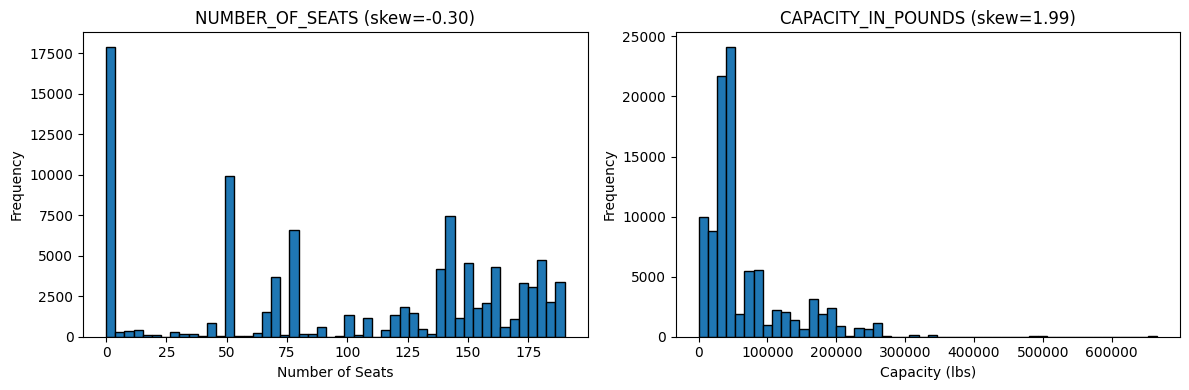

In [85]:
#histograms before transformation
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(aircraft_clean['NUMBER_OF_SEATS'], bins=50, edgecolor='black')
axes[0].set_title(f'NUMBER_OF_SEATS (skew={seats_skew:.2f})')
axes[0].set_xlabel('Number of Seats')
axes[0].set_ylabel('Frequency')

axes[1].hist(aircraft_clean['CAPACITY_IN_POUNDS'], bins=50, edgecolor='black')
axes[1].set_title(f'CAPACITY_IN_POUNDS (skew={cap_skew:.2f})')
axes[1].set_xlabel('Capacity (lbs)')
axes[1].set_ylabel('Frequency')

plt.tight_layout()
plt.show()

`NUMBER_OF_SEATS` is slightly left-skewed (-0.30) with a large spike near 0. This is likely cargo aircraft with no passenger seats. `CAPACITY_IN_POUNDS` is right-skewed (1.99) with a long tail from heavy cargo planes.

We'll apply the Box-Cox transformation to make both distributions more symmetric. Box-Cox requires strictly positive values, so we check for zeros first and shift by +1 if needed.

In [88]:
print("Zeros in NUMBER_OF_SEATS:", (aircraft_clean['NUMBER_OF_SEATS'] == 0).sum())
print("Zeros in CAPACITY_IN_POUNDS:", (aircraft_clean['CAPACITY_IN_POUNDS'] == 0).sum())

Zeros in NUMBER_OF_SEATS: 17859
Zeros in CAPACITY_IN_POUNDS: 2025


In [94]:
#applying boxcox transformation
seats_boxcox, seats_lambda = stats.boxcox(aircraft_clean['NUMBER_OF_SEATS'] + 1)
cap_boxcox, cap_lambda = stats.boxcox(aircraft_clean['CAPACITY_IN_POUNDS'] + 1)

aircraft_clean = aircraft_clean.copy()
aircraft_clean['NUMBER_OF_SEATS_BOXCOX'] = seats_boxcox
aircraft_clean['CAPACITY_IN_POUNDS_BOXCOX'] = cap_boxcox

print(f"NUMBER_OF_SEATS lambda: {seats_lambda:.4f}")
print(f"CAPACITY_IN_POUNDS lambda: {cap_lambda:.4f}")

NUMBER_OF_SEATS lambda: 0.6192
CAPACITY_IN_POUNDS lambda: 0.3632


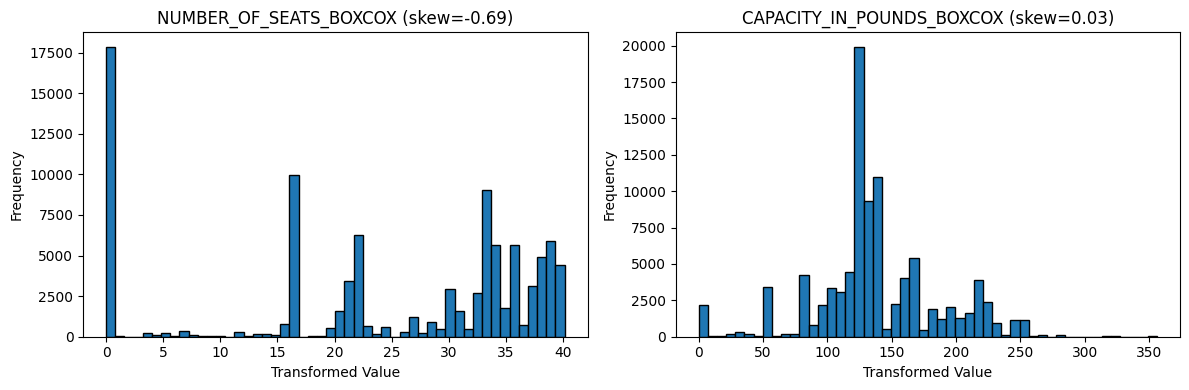

In [96]:
#histograms after transformation
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

seats_bc_skew = aircraft_clean['NUMBER_OF_SEATS_BOXCOX'].skew()
cap_bc_skew = aircraft_clean['CAPACITY_IN_POUNDS_BOXCOX'].skew()

axes[0].hist(aircraft_clean['NUMBER_OF_SEATS_BOXCOX'], bins=50, edgecolor='black')
axes[0].set_title(f'NUMBER_OF_SEATS_BOXCOX (skew={seats_bc_skew:.2f})')
axes[0].set_xlabel('Transformed Value')
axes[0].set_ylabel('Frequency')

axes[1].hist(aircraft_clean['CAPACITY_IN_POUNDS_BOXCOX'], bins=50, edgecolor='black')
axes[1].set_title(f'CAPACITY_IN_POUNDS_BOXCOX (skew={cap_bc_skew:.2f})')
axes[1].set_xlabel('Transformed Value')
axes[1].set_ylabel('Frequency')

plt.tight_layout()
plt.show()

| Column | Skewness Before | Skewness After | Box-Cox Lambda |
|--------|----------------|---------------|----------------|
| NUMBER_OF_SEATS | -0.30 | -0.69 | 0.62 |
| CAPACITY_IN_POUNDS | 1.99 | 0.03 | 0.36 |

**Task 4 Observations**

- Before transformation: `NUMBER_OF_SEATS` has a skewness of -0.30 so it's roughly symmetric, but looking at the histogram it has a big spike at 0 which is probably cargo planes with no passenger seats. The distribution looks multimodal. There seem to be clusters at different seat counts for different types of aircraft. `CAPACITY_IN_POUNDS` is pretty heavily right-skewed at 1.99. Most planes are under 100k lbs but there are some really heavy ones pulling the tail out.

- After Box-Cox: `CAPACITY_IN_POUNDS` improved a lot. Skewness went from 1.99 down to 0.03 which is basically perfectly symmetric. The lambda was 0.36 which is close to a cube root transformation. `NUMBER_OF_SEATS` actually got a bit worse, going from -0.30 to -0.69. I think this is because Box-Cox assumes the data is unimodal and skewed, but our seats data has that big zero cluster from cargo planes which throws it off. It can't really fix a distribution that has two separate groups like that.

### Task 5: Feature Engineering

In [99]:
#quartiles
aircraft_clean['NUMBER_OF_SEATS'].describe()

count    96047.000000
mean        99.871547
std         65.322380
min          0.000000
25%         50.000000
50%        120.000000
75%        157.000000
max        190.000000
Name: NUMBER_OF_SEATS, dtype: float64

In [105]:
#creating size columns
q25 = aircraft_clean['NUMBER_OF_SEATS'].quantile(0.25)
q50 = aircraft_clean['NUMBER_OF_SEATS'].quantile(0.50)
q75 = aircraft_clean['NUMBER_OF_SEATS'].quantile(0.75)

print("25th percentile:", q25)
print("50th percentile:", q50)
print("75th percentile:", q75)

def create_size_column(df, q25, q50, q75):
    conditions = [
        df['NUMBER_OF_SEATS'] <= q25,
        (df['NUMBER_OF_SEATS'] > q25) & (df['NUMBER_OF_SEATS'] <= q50),
        (df['NUMBER_OF_SEATS'] > q50) & (df['NUMBER_OF_SEATS'] <= q75),
        df['NUMBER_OF_SEATS'] > q75
    ]
    labels = ['SMALL', 'MEDIUM', 'LARGE', 'XLARGE']
    df['SIZE'] = np.select(conditions, labels, default='UNKNOWN')
    return df

aircraft_clean = create_size_column(aircraft_clean, q25, q50, q75)
aircraft_clean['SIZE'].value_counts()

25th percentile: 50.0
50th percentile: 120.0
75th percentile: 157.0


SIZE
SMALL     30708
LARGE     24644
XLARGE    23107
MEDIUM    17588
Name: count, dtype: int64

In [109]:
#operating status proportions by size
op_props = pd.crosstab(aircraft_clean['SIZE'], aircraft_clean['OPERATING_STATUS'], normalize='index')
op_props

OPERATING_STATUS,N,Y
SIZE,,
LARGE,0.034978,0.965022
MEDIUM,0.043723,0.956277
SMALL,0.049368,0.950632
XLARGE,0.027481,0.972519


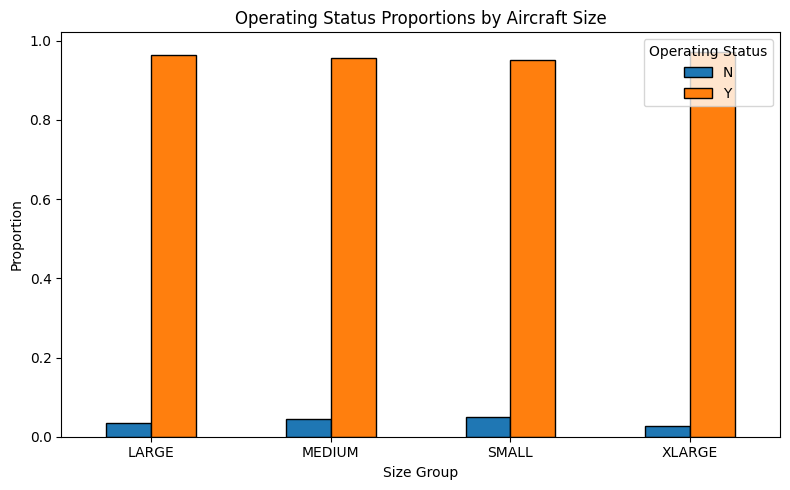

In [107]:
#plots
op_props.plot(kind='bar', figsize=(8, 5), edgecolor='black')
plt.title('Operating Status Proportions by Aircraft Size')
plt.xlabel('Size Group')
plt.ylabel('Proportion')
plt.legend(title='Operating Status')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [108]:
#aircraft size proportions by size
status_props = pd.crosstab(aircraft_clean['SIZE'], aircraft_clean['AIRCRAFT_STATUS'], normalize='index')
status_props

AIRCRAFT_STATUS,A,B,L,O
SIZE,,,,
LARGE,0.142306,0.202280,0.001988,0.653425
MEDIUM,0.048328,0.434217,0.001649,0.515806
SMALL,0.041488,0.386577,0.000000,0.571936
XLARGE,0.064526,0.237374,0.001342,0.696759


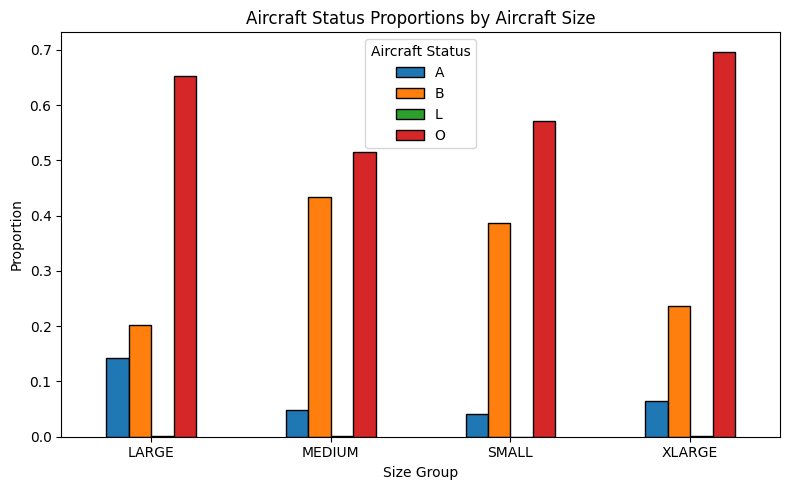

In [110]:
#plots for the same
status_props.plot(kind='bar', figsize=(8, 5), edgecolor='black')
plt.title('Aircraft Status Proportions by Aircraft Size')
plt.xlabel('Size Group')
plt.ylabel('Proportion')
plt.legend(title='Aircraft Status')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

**Task 5 Summary**

***Operating status:*** The proportions are pretty similar across all size groups. Around 95-97% are operating (Y) regardless of size. XLARGE aircraft have the highest operating rate (97.3%) and SMALL aircraft have the lowest (95.1%), but the differences are small. Size doesn't seem to be a major factor in whether an aircraft is currently operating.

***Aircraft status:*** This is where the differences are more interesting.
- Status `O` (owned) is most common across all groups, but XLARGE aircraft have the highest proportion at 69.7% while MEDIUM aircraft have the lowest at 51.6%.
- Status `B` (bought/leased) is highest for MEDIUM (43.4%) and SMALL (38.7%) aircraft, and lowest for LARGE (20.2%) and XLARGE (23.7%). Smaller aircraft seem more likely to be leased.
- Status `A` (assigned) stands out for LARGE aircraft at 14.2%, much higher than the other groups (4-6%).
- Status `L` is very rare across all groups (< 0.2%).

Overall, larger aircraft tend to be owned outright while smaller/medium aircraft are more likely to be leased.

### Task 6: Modeling Refresher

In [111]:
#prepare features
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error

#numeric columns for features for modeling
numeric_cols = ['YEAR', 'MANUFACTURE_YEAR', 'NUMBER_OF_SEATS', 'CAPACITY_IN_POUNDS']

In [113]:
#train test split
#features for predicting NUMBER_OF_SEATS
X_seats = aircraft_clean[['YEAR', 'MANUFACTURE_YEAR', 'CAPACITY_IN_POUNDS']]
y_seats = aircraft_clean['NUMBER_OF_SEATS']

#features for predicting CAPACITY_IN_POUNDS
X_cap = aircraft_clean[['YEAR', 'MANUFACTURE_YEAR', 'NUMBER_OF_SEATS']]
y_cap = aircraft_clean['CAPACITY_IN_POUNDS']

X_seats_train, X_seats_test, y_seats_train, y_seats_test = train_test_split(X_seats, y_seats, test_size=0.2, random_state=42)
X_cap_train, X_cap_test, y_cap_train, y_cap_test = train_test_split(X_cap, y_cap, test_size=0.2, random_state=42)

print("Training size:", len(X_seats_train))
print("Testing size:", len(X_seats_test))

Training size: 76837
Testing size: 19210


In [119]:
#linear regression for NUMBER_OF_SEATS
lr_seats = LinearRegression()
lr_seats.fit(X_seats_train, y_seats_train)

lr_seats_train_rmse = mean_squared_error(y_seats_train, lr_seats.predict(X_seats_train)) ** 0.5
lr_seats_test_rmse = mean_squared_error(y_seats_test, lr_seats.predict(X_seats_test)) ** 0.5
print(f"Linear Regression - NUMBER_OF_SEATS")
print(f"  Train RMSE: {lr_seats_train_rmse:.2f}")
print(f"  Test RMSE:  {lr_seats_test_rmse:.2f}")

Linear Regression - NUMBER_OF_SEATS
  Train RMSE: 64.90
  Test RMSE:  64.54


In [120]:
#linear regression for CAPACITY_IN_POUNDS
lr_cap = LinearRegression()
lr_cap.fit(X_cap_train, y_cap_train)

lr_cap_train_rmse = mean_squared_error(y_cap_train, lr_cap.predict(X_cap_train)) ** 0.5
lr_cap_test_rmse = mean_squared_error(y_cap_test, lr_cap.predict(X_cap_test)) ** 0.5
print(f"Linear Regression - CAPACITY_IN_POUNDS")
print(f"  Train RMSE: {lr_cap_train_rmse:.2f}")
print(f"  Test RMSE:  {lr_cap_test_rmse:.2f}")

Linear Regression - CAPACITY_IN_POUNDS
  Train RMSE: 59447.40
  Test RMSE:  59022.43


In [121]:
#random forest for NUMBER_OF_SEATS
rf_seats = RandomForestRegressor(n_estimators=100, random_state=42)
rf_seats.fit(X_seats_train, y_seats_train)

rf_seats_train_rmse = mean_squared_error(y_seats_train, rf_seats.predict(X_seats_train)) ** 0.5
rf_seats_test_rmse = mean_squared_error(y_seats_test, rf_seats.predict(X_seats_test)) ** 0.5
print(f"Random Forest - NUMBER_OF_SEATS")
print(f"  Train RMSE: {rf_seats_train_rmse:.2f}")
print(f"  Test RMSE:  {rf_seats_test_rmse:.2f}")

Random Forest - NUMBER_OF_SEATS
  Train RMSE: 5.62
  Test RMSE:  8.37


In [122]:
#random forest for CAPACITY_IN_POUNDS
rf_cap = RandomForestRegressor(n_estimators=100, random_state=42)
rf_cap.fit(X_cap_train, y_cap_train)

rf_cap_train_rmse = mean_squared_error(y_cap_train, rf_cap.predict(X_cap_train)) ** 0.5
rf_cap_test_rmse = mean_squared_error(y_cap_test, rf_cap.predict(X_cap_test)) ** 0.5
print(f"Random Forest - CAPACITY_IN_POUNDS")
print(f"  Train RMSE: {rf_cap_train_rmse:.2f}")
print(f"  Test RMSE:  {rf_cap_test_rmse:.2f}")

Random Forest - CAPACITY_IN_POUNDS
  Train RMSE: 33098.31
  Test RMSE:  35356.36


In [125]:
#summary of results
results = pd.DataFrame({
    'Model': ['Linear Regression', 'Linear Regression', 'Random Forest', 'Random Forest'],
    'Target': ['NUMBER_OF_SEATS', 'CAPACITY_IN_POUNDS', 'NUMBER_OF_SEATS', 'CAPACITY_IN_POUNDS'],
    'Train RMSE': [lr_seats_train_rmse, lr_cap_train_rmse, rf_seats_train_rmse, rf_cap_train_rmse],
    'Test RMSE': [lr_seats_test_rmse, lr_cap_test_rmse, rf_seats_test_rmse, rf_cap_test_rmse]
})
results['Train RMSE'] = results['Train RMSE'].round(2)
results['Test RMSE'] = results['Test RMSE'].round(2)
print(results.to_string(index=False))

            Model             Target  Train RMSE  Test RMSE
Linear Regression    NUMBER_OF_SEATS       64.90      64.54
Linear Regression CAPACITY_IN_POUNDS    59447.40   59022.43
    Random Forest    NUMBER_OF_SEATS        5.62       8.37
    Random Forest CAPACITY_IN_POUNDS    33098.31   35356.36


**Task 6 Observations**

***Random forest vs linear regression:*** Random forest performed much better than linear regression for both targets. For seats, test RMSE dropped from 64.54 to 8.37, which is a huge improvement. For capacity, it went from 59,022 to 35,356, a solid improvement but not as dramatic.

***Train vs test error:*** Linear regression has very similar train and test RMSE, meaning it's not overfitting but it's also not capturing the complexity of the data well (underfitting). Random forest has noticeably lower train RMSE than test RMSE (e.g. 5.62 vs 8.37 for seats), which suggests some overfitting, but the test error is still way better than linear regression so the tradeoff is worth it.

***Seats vs capacity:*** Predicting `NUMBER_OF_SEATS` was easier. Random forest got it down to an RMSE of 8.37 seats, which is pretty accurate. `CAPACITY_IN_POUNDS` was harder to predict with a test RMSE of 35,356 lbs, though that makes sense since capacity values are in the tens/hundreds of thousands so the scale is much larger. The relationship between the features and capacity is probably more complex and less linear.

**Generative AI Disclosure**

I used Claude AI for brainstorming imputation strategies, debugging code errors, and drafting documentation of my observations. Some of the key prompts included asking for help with missing data investigation approaches, Box-Cox transformation usage, and interpreting model results and plots made. All code was reviewed, run, and verified by me manually against the dataset. I also checked outputs to make sure they made sense with the BTS documentation.